In [284]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/fernandol/countries-of-the-world/countries of the world.csv


In [285]:
df = pd.read_csv('/kaggle/input/datasets/fernandol/countries-of-the-world/countries of the world.csv')

df.head()

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,"48,0","0,00","23,06","163,07",700.0,"36,0","3,2","12,13","0,22","87,65",1,"46,6","20,34","0,38","0,24","0,38"
1,Albania,EASTERN EUROPE,3581655,28748,"124,6","1,26","-4,93","21,52",4500.0,"86,5","71,2","21,09","4,42","74,49",3,"15,11","5,22","0,232","0,188","0,579"
2,Algeria,NORTHERN AFRICA,32930091,2381740,"13,8","0,04","-0,39",31,6000.0,"70,0","78,1","3,22","0,25","96,53",1,"17,14","4,61","0,101","0,6","0,298"
3,American Samoa,OCEANIA,57794,199,"290,4","58,29","-20,71","9,27",8000.0,"97,0","259,5",10,15,75,2,"22,46","3,27",NaN,NaN,NaN
4,Andorra,WESTERN EUROPE,71201,468,"152,1","0,00","6,6","4,05",19000.0,"100,0","497,2","2,22",0,"97,78",3,"8,71","6,25",NaN,NaN,NaN


In [286]:
df_new = df.drop(columns = ['Country','Region'])
df_new

,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,31056997,647500,"48,0","0,00","23,06","163,07",700.0,"36,0","3,2","12,13","0,22","87,65",1,"46,6","20,34","0,38","0,24","0,38"
1,3581655,28748,"124,6","1,26","-4,93","21,52",4500.0,"86,5","71,2","21,09","4,42","74,49",3,"15,11","5,22","0,232","0,188","0,579"
2,32930091,2381740,"13,8","0,04","-0,39",31,6000.0,"70,0","78,1","3,22","0,25","96,53",1,"17,14","4,61","0,101","0,6","0,298"
3,57794,199,"290,4","58,29","-20,71","9,27",8000.0,"97,0","259,5",10,15,75,2,"22,46","3,27",NaN,NaN,NaN
4,71201,468,"152,1","0,00","6,6","4,05",19000.0,"100,0","497,2","2,22",0,"97,78",3,"8,71","6,25",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222,2460492,5860,"419,9","0,00","2,98","19,62",800.0,NaN,"145,2","16,9","18,97","64,13",3,"31,67","3,92","0,09","0,28","0,63"
223,273008,266000,"1,0","0,42",NaN,NaN,NaN,NaN,NaN,"0,02",0,"99,98",1,NaN,NaN,NaN,NaN,"0,4"
224,21456188,527970,"40,6","0,36",0,"61,5",800.0,"50,2","37,2","2,78","0,24","96,98",1,"42,89","8,3","0,135","0,472","0,393"
225,11502010,752614,"15,3","0,00",0,"88,29",800.0,"80,6","8,2","7,08","0,03","92,9",2,41,"19,93","0,22","0,29","0,489"


In [287]:
df_new.isnull().sum()

Population                             0
Area (sq. mi.)                         0
Pop. Density (per sq. mi.)             0
Coastline (coast/area ratio)           0
Net migration                          3
Infant mortality (per 1000 births)     3
GDP ($ per capita)                     1
Literacy (%)                          18
Phones (per 1000)                      4
Arable (%)                             2
Crops (%)                              2
Other (%)                              2
Climate                               22
Birthrate                              3
Deathrate                              4
Agriculture                           15
Industry                              16
Service                               15
dtype: int64

**CHANGED ALL OBJECT DATA TYPES TO FLOAT NECCESARY FOR IMPUTING**

In [288]:
object_cols = df_new.select_dtypes(include='object').columns

for col in object_cols:
    df_new[col] = df_new[col].str.replace(',', '.').astype(float)

In [289]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 18 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Population                          227 non-null    int64  
 1   Area (sq. mi.)                      227 non-null    int64  
 2   Pop. Density (per sq. mi.)          227 non-null    float64
 3   Coastline (coast/area ratio)        227 non-null    float64
 4   Net migration                       224 non-null    float64
 5   Infant mortality (per 1000 births)  224 non-null    float64
 6   GDP ($ per capita)                  226 non-null    float64
 7   Literacy (%)                        209 non-null    float64
 8   Phones (per 1000)                   223 non-null    float64
 9   Arable (%)                          225 non-null    float64
 10  Crops (%)                           225 non-null    float64
 11  Other (%)                           225 non-n

**IMPUTING THE MISSING VALUE USED SIMPLPE AS WE HAVE LESS NUMBER OF MISSING VALUES**

In [290]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy = 'mean')

df_imputed = pd.DataFrame(imputer.fit_transform(df_new), columns=df_new.columns)

In [291]:
df_imputed

,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,31056997.0,647500.0,48.0,0.00,23.060000,163.070000,700.000000,36.000000,3.200000,12.13,0.22,87.65,1.0,46.600000,20.340000,0.380000,0.240000,0.380000
1,3581655.0,28748.0,124.6,1.26,-4.930000,21.520000,4500.000000,86.500000,71.200000,21.09,4.42,74.49,3.0,15.110000,5.220000,0.232000,0.188000,0.579000
2,32930091.0,2381740.0,13.8,0.04,-0.390000,31.000000,6000.000000,70.000000,78.100000,3.22,0.25,96.53,1.0,17.140000,4.610000,0.101000,0.600000,0.298000
3,57794.0,199.0,290.4,58.29,-20.710000,9.270000,8000.000000,97.000000,259.500000,10.00,15.00,75.00,2.0,22.460000,3.270000,0.150844,0.282711,0.565283
4,71201.0,468.0,152.1,0.00,6.600000,4.050000,19000.000000,100.000000,497.200000,2.22,0.00,97.78,3.0,8.710000,6.250000,0.150844,0.282711,0.565283
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222,2460492.0,5860.0,419.9,0.00,2.980000,19.620000,800.000000,82.838278,145.200000,16.90,18.97,64.13,3.0,31.670000,3.920000,0.090000,0.280000,0.630000
223,273008.0,266000.0,1.0,0.42,0.038125,35.506964,9689.823009,82.838278,236.061435,0.02,0.00,99.98,1.0,22.114732,9.241345,0.150844,0.282711,0.400000
224,21456188.0,527970.0,40.6,0.36,0.000000,61.500000,800.000000,50.200000,37.200000,2.78,0.24,96.98,1.0,42.890000,8.300000,0.135000,0.472000,0.393000
225,11502010.0,752614.0,15.3,0.00,0.000000,88.290000,800.000000,80.600000,8.200000,7.08,0.03,92.90,2.0,41.000000,19.930000,0.220000,0.290000,0.489000


In [292]:
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 18 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Population                          227 non-null    float64
 1   Area (sq. mi.)                      227 non-null    float64
 2   Pop. Density (per sq. mi.)          227 non-null    float64
 3   Coastline (coast/area ratio)        227 non-null    float64
 4   Net migration                       227 non-null    float64
 5   Infant mortality (per 1000 births)  227 non-null    float64
 6   GDP ($ per capita)                  227 non-null    float64
 7   Literacy (%)                        227 non-null    float64
 8   Phones (per 1000)                   227 non-null    float64
 9   Arable (%)                          227 non-null    float64
 10  Crops (%)                           227 non-null    float64
 11  Other (%)                           227 non-n

**CHECKING OUTLIERS**

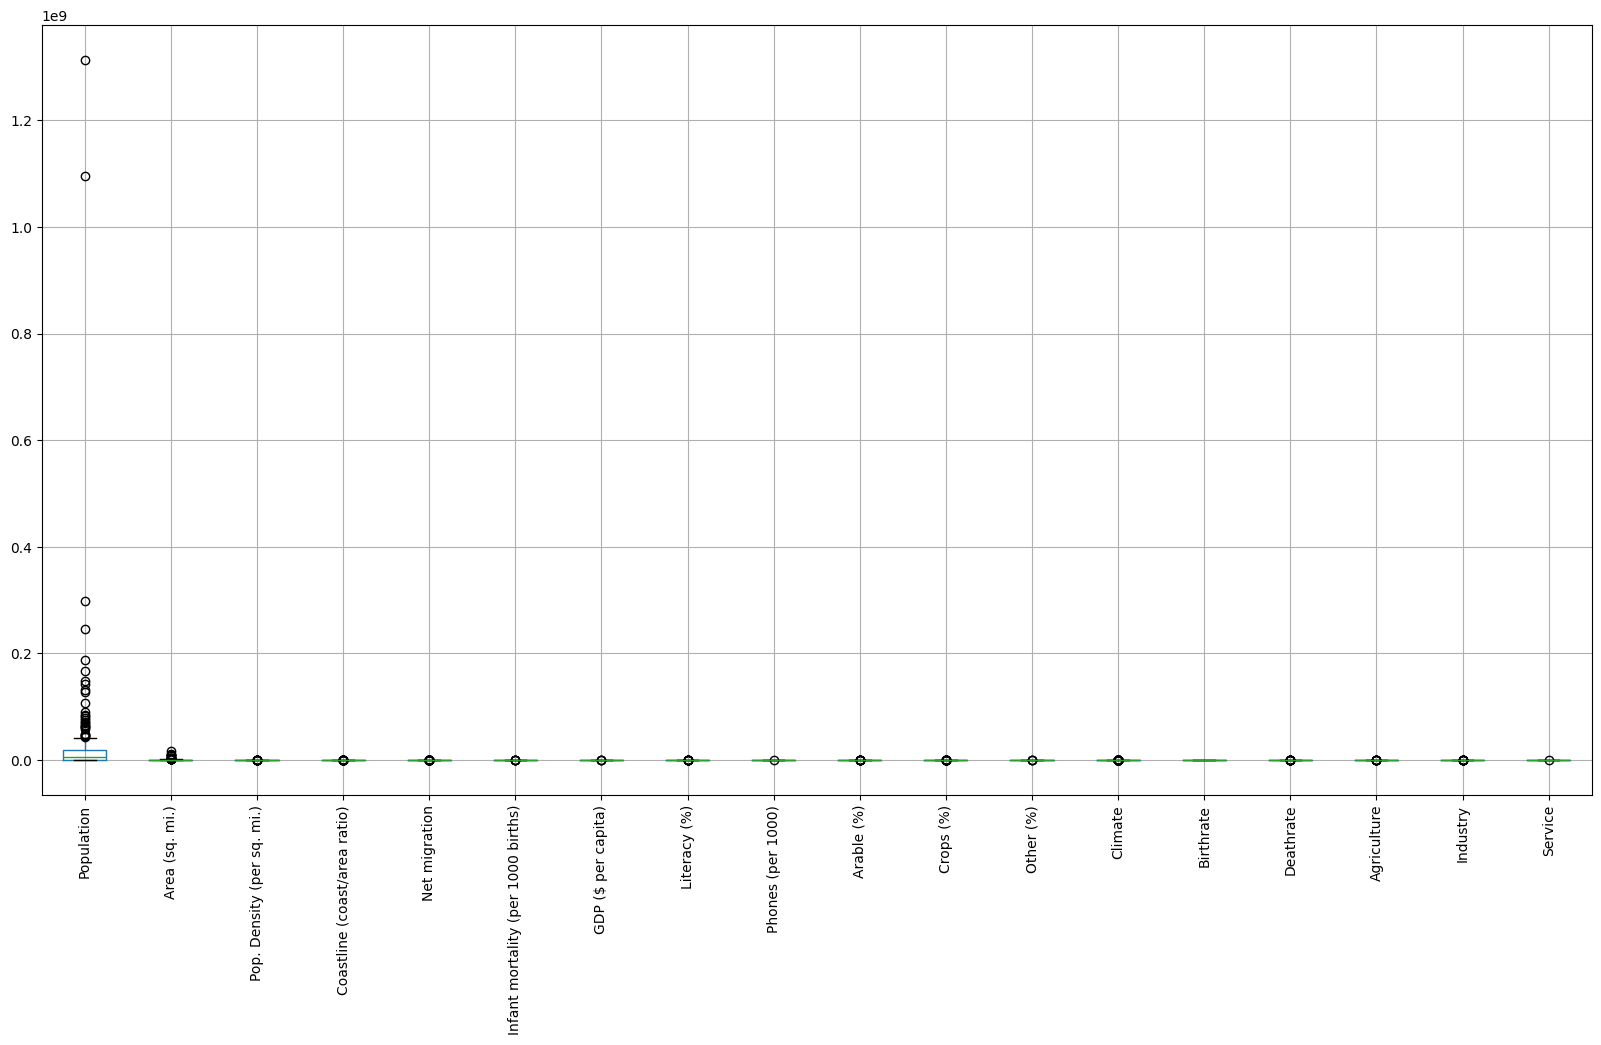

In [293]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
df_imputed.boxplot()
plt.xticks(rotation=90)
plt.show()

In [294]:
df_imputed.skew()

Population                            9.200223
Area (sq. mi.)                        5.964245
Pop. Density (per sq. mi.)            8.284886
Coastline (coast/area ratio)          8.221680
Net migration                         0.128241
Infant mortality (per 1000 births)    1.439358
GDP ($ per capita)                    1.378924
Literacy (%)                         -1.268439
Phones (per 1000)                     1.025020
Arable (%)                            1.340559
Crops (%)                             3.239335
Other (%)                            -0.960525
Climate                               0.368292
Birthrate                             0.712622
Deathrate                             1.667097
Agriculture                           1.467287
Industry                              1.139959
Service                              -0.141634
dtype: float64

In [295]:
Q1 = df_imputed.quantile(0.25)
Q3 = df_imputed.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df_imputed < (Q1 - 1.5 * IQR)) | (df_imputed > (Q3 + 1.5 * IQR))).sum()
print(outliers)

Population                            28
Area (sq. mi.)                        28
Pop. Density (per sq. mi.)            21
Coastline (coast/area ratio)          37
Net migration                         52
Infant mortality (per 1000 births)     5
GDP ($ per capita)                     3
Literacy (%)                          16
Phones (per 1000)                      1
Arable (%)                            10
Crops (%)                             29
Other (%)                              3
Climate                               91
Birthrate                              0
Deathrate                             16
Agriculture                            8
Industry                              12
Service                                1
dtype: int64


we have genuine outliers so we could not afford either removing or capping them we need to scale it for sure so we used robust scaler as standard scaler is sensitive to ouliers

In [296]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = scaler.fit_transform(df_imputed)


In [297]:
X_scaled

array([[ 1.53984609,  1.28304399, -0.19130435, ...,  1.54385965,
        -0.31111111, -0.81264482],
       [-0.07065232, -0.13233493,  0.28447205, ...,  0.67836257,
        -0.6962963 ,  0.0601622 ],
       [ 1.64963963,  5.25007234, -0.40372671, ..., -0.0877193 ,
         2.35555556, -1.17229394],
       ...,
       [ 0.97708376,  1.00962226, -0.23726708, ...,  0.11111111,
         1.40740741, -0.75562728],
       [ 0.3936083 ,  1.5234895 , -0.39440994, ...,  0.60818713,
         0.05925926, -0.33457464],
       [ 0.43667914,  0.69534625, -0.29503106, ...,  0.36842105,
        -0.28888889,  0.0601622 ]])

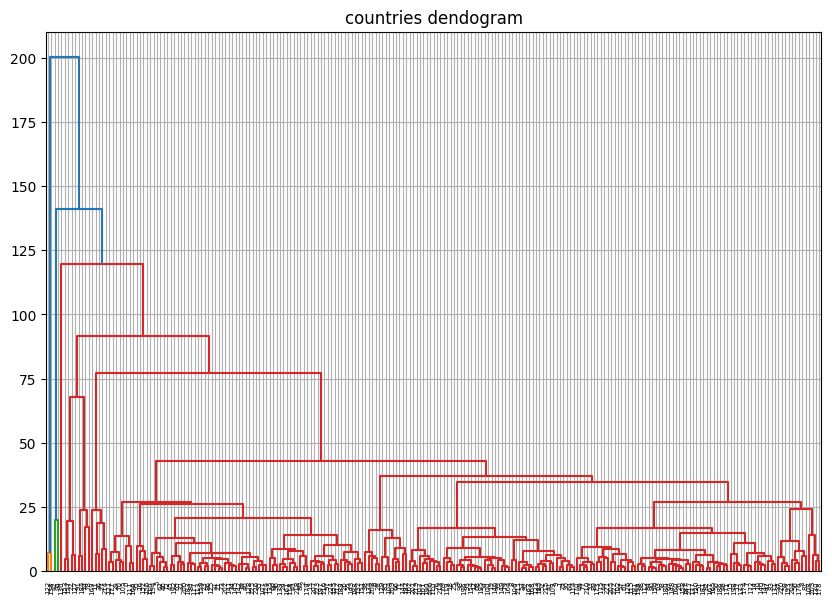

In [298]:
import scipy.cluster.hierarchy as shc 
plt.figure(figsize = (10,7))
plt.title('countries dendogram')
dend = shc.dendrogram(shc.linkage(X_scaled,method = 'ward'))
plt.grid()

In [299]:
india_index = df[df['Country'].str.strip() == 'India'].index[0]
print(india_index)

94


In [300]:
from sklearn.cluster import AgglomerativeClustering
model = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = model.fit_predict(X_scaled)

In [304]:
labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0])

In [301]:
# from sklearn.decomposition import PCA
# import matplotlib.pyplot as plt

# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_scaled)

# plt.figure(figsize=(10, 6))
# plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='rainbow')

In [302]:
india_cluster = labels[india_index]
print("India is in cluster:", india_cluster)

India is in cluster: 2


In [303]:
india_neighbours = df['Country'][labels == india_cluster]
print(india_neighbours.values)

['China ' 'India ']
